# Imports

In [1]:
# Data 
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


# model stuff 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Data Cleaning 

In [2]:
df = pd.read_csv('Credit_Card_Applications.csv')
df.head()

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,15776156,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [3]:
df.info()
# no missing/null values at all 

<class 'pandas.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  690 non-null    int64  
 1   A1          690 non-null    int64  
 2   A2          690 non-null    float64
 3   A3          690 non-null    float64
 4   A4          690 non-null    int64  
 5   A5          690 non-null    int64  
 6   A6          690 non-null    int64  
 7   A7          690 non-null    float64
 8   A8          690 non-null    int64  
 9   A9          690 non-null    int64  
 10  A10         690 non-null    int64  
 11  A11         690 non-null    int64  
 12  A12         690 non-null    int64  
 13  A13         690 non-null    int64  
 14  A14         690 non-null    int64  
 15  Class       690 non-null    int64  
dtypes: float64(3), int64(13)
memory usage: 86.4 KB


In [4]:
df.nunique()

CustomerID    690
A1              2
A2            350
A3            215
A4              3
A5             14
A6              8
A7            132
A8              2
A9              2
A10            23
A11             2
A12             3
A13           171
A14           240
Class           2
dtype: int64

In [5]:
print(df.shape)
print(df.columns)

(690, 16)
Index(['CustomerID', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9',
       'A10', 'A11', 'A12', 'A13', 'A14', 'Class'],
      dtype='str')


In [6]:
df.duplicated().sum()
# no dups 

np.int64(0)

In [7]:
df['Class'].value_counts(normalize=True)
# checking for class imbalance

Class
0    0.555072
1    0.444928
Name: proportion, dtype: float64

In [8]:
df.drop(columns=["CustomerID"], inplace=True)
# no need for this column, it is just an identifier

# Exploratory Data Analysis 

In [9]:
df.describe()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
count,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.00000,690.000000,690.000000,690.000000,690.000000,690.000000
mean,0.678261,31.568203,4.758725,1.766667,7.372464,4.692754,2.223406,0.523188,0.427536,2.40000,0.457971,1.928986,184.014493,1018.385507,0.444928
std,0.467482,11.853273,4.978163,0.430063,3.683265,1.992316,3.346513,0.499824,0.495080,4.86294,0.498592,0.298813,172.159274,5210.102598,0.497318
min,0.000000,13.750000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,0.000000,22.670000,1.000000,2.000000,4.000000,4.000000,0.165000,0.000000,0.000000,0.00000,0.000000,2.000000,80.000000,1.000000,0.000000
50%,1.000000,28.625000,2.750000,2.000000,8.000000,4.000000,1.000000,1.000000,0.000000,0.00000,0.000000,2.000000,160.000000,6.000000,0.000000
75%,1.000000,37.707500,7.207500,2.000000,10.000000,5.000000,2.625000,1.000000,1.000000,3.00000,1.000000,2.000000,272.000000,396.500000,1.000000
max,1.000000,80.250000,28.000000,3.000000,14.000000,9.000000,28.500000,1.000000,1.000000,67.00000,1.000000,3.000000,2000.000000,100001.000000,1.000000


## Using info from df.describe() and df.nunique(), we can categorize the columns into categorical and continuous features.

In [10]:
categorical_cols = [
    'A1',
    'A4',
    'A5',
    'A6',
    'A8',
    'A9',
    'A10',
    'A11',
    'A12'
]

numerical_cols = [
    'A2',
    'A3',
    'A7',
    'A13',
    'A14'
]

## Checking for bias in approval rates for categorical features 

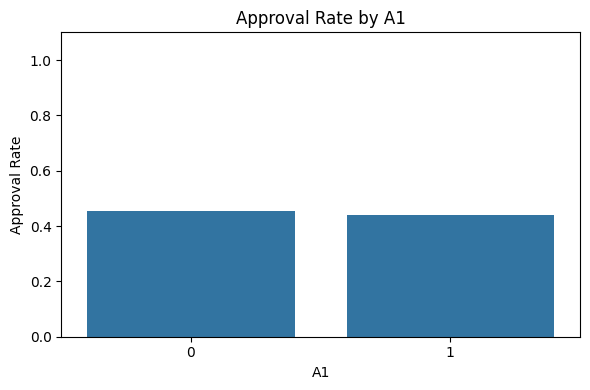

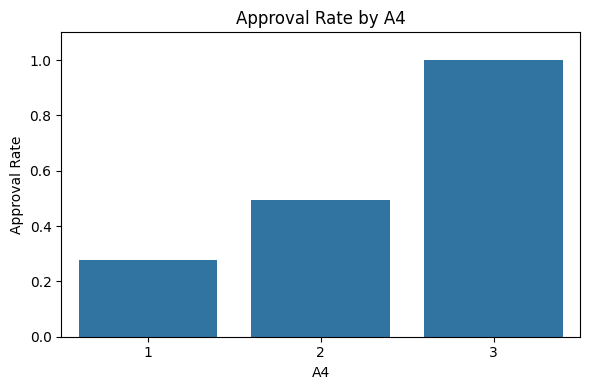

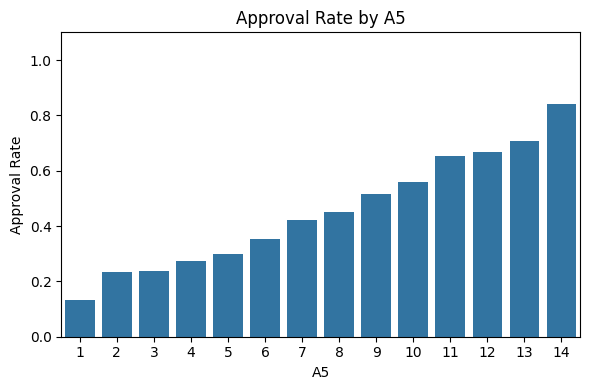

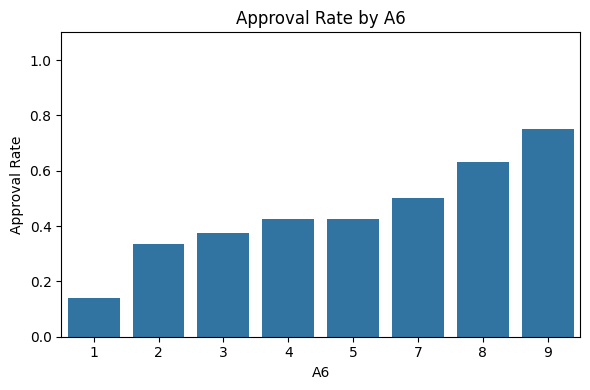

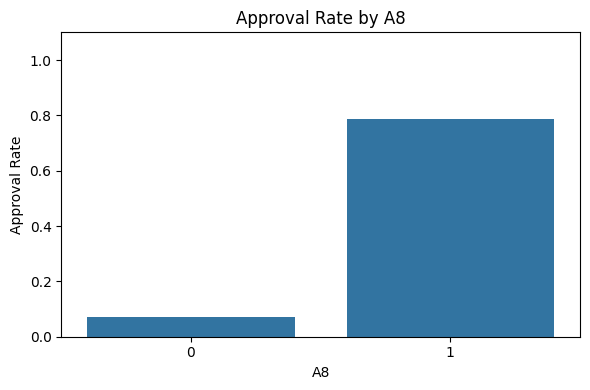

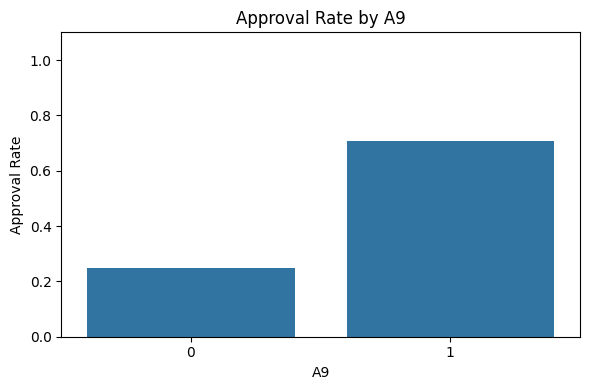

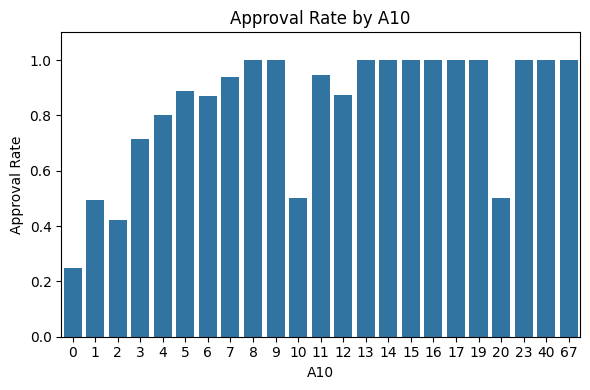

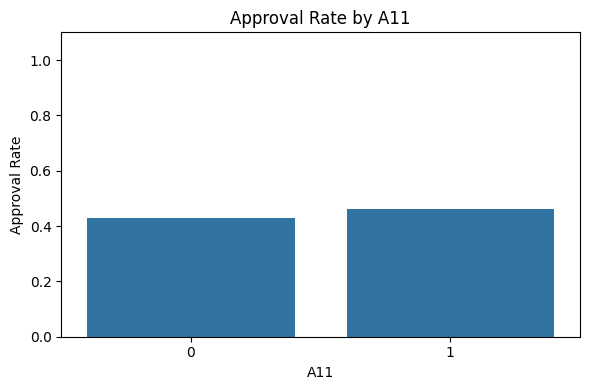

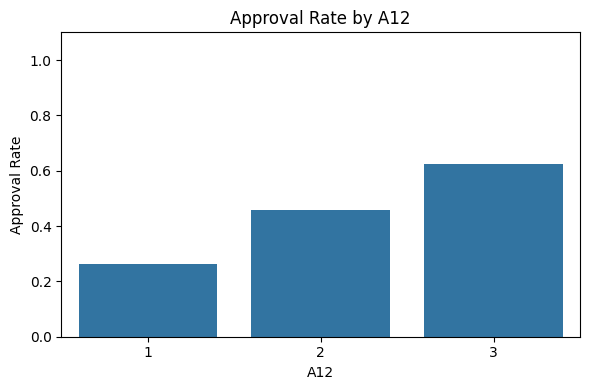

In [11]:
for col in categorical_cols:
    
    summary = (
        df.groupby(col)['Class']
        .agg(['mean', 'count'])
        .reset_index()
    )

    plt.figure(figsize=(6, 4))

    ax = sns.barplot(
        data=summary,
        x=col,
        y='mean'
    )

    # add count labels on bars
    '''for i, row in summary.iterrows():
        ax.text(
            i,
            row['mean'] + 0.02,
            f"{row['count']}",
            ha='center'
        )'''

    plt.title(f'Approval Rate by {col}')
    plt.ylabel('Approval Rate')
    plt.ylim(0, 1.1)

    plt.tight_layout()
    plt.show()

- We reviewed categorical feaatures, but their meanings were too unclear to confidently label as protected attributes.
- Columns with contrasting approval rates could be bias or actual important indicators for approval rate. 
- Rather than removing features based mostly on assumptions, we chose a more conservative approach and only removed the strongest suspected demographic signal.

## Checking for outliers using Boxplots

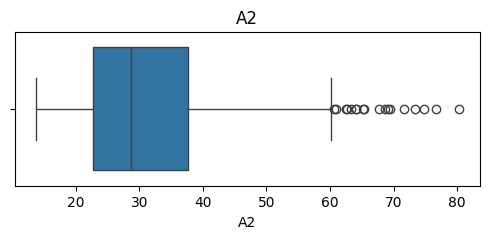

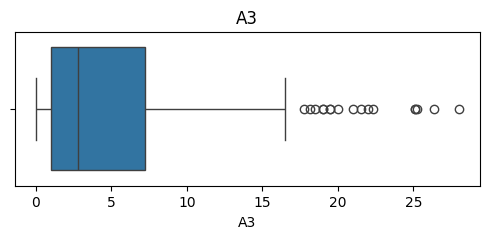

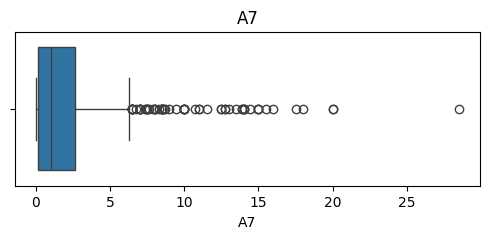

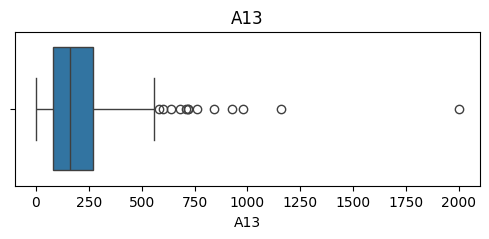

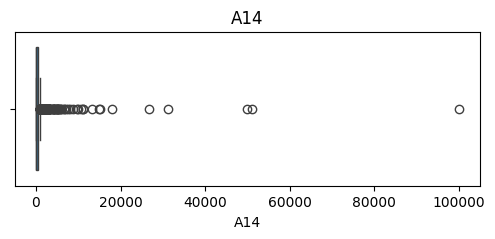

In [12]:
for col in numerical_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

## Removing outliers using 95th percentile as upper bound

In [13]:
rows_before = df.shape[0]

for col in numerical_cols:

    upper_bound = df[col].quantile(0.95)

    df = df[
        df[col] <= upper_bound
    ]

rows_after = df.shape[0]

rows_removed = rows_before - rows_after

print(f"Outliers removed: {rows_removed}")
print(f"Percent removed: {(rows_removed / rows_before) * 100:.2f}%")

Outliers removed: 155
Percent removed: 22.46%


## check if outliers removed using Boxplots

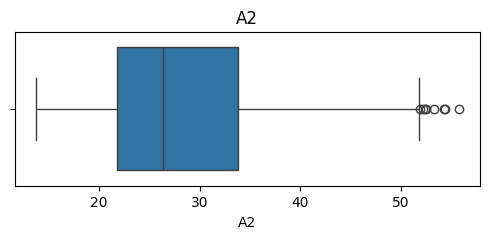

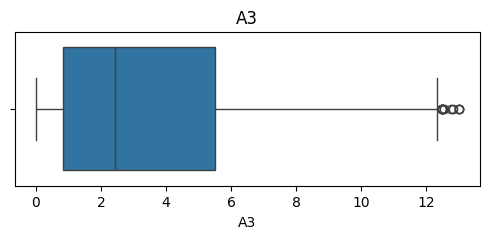

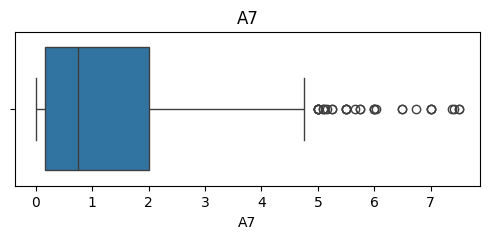

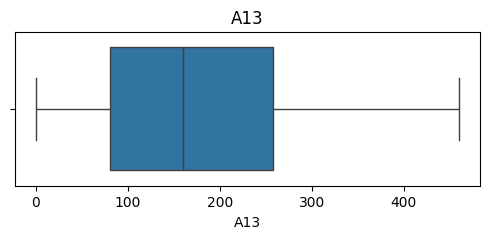

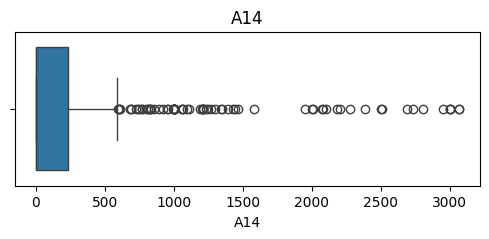

In [14]:
for col in numerical_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

- We will remove A2 because it strongly resembled age-related data.
- Its range (~14–80) looked much more like a demographic feature than a financial one, so we excluded it to reduce possible age bias in clustering.

In [15]:
df = df.drop(columns=["A2"])
numerical_cols.remove("A2")

In [16]:
df_original = df.copy() 
df = df.drop(columns=["Class"])

- We save original df before dropping class for later analysis 
- Drop Class columns as it can negatively affect clustering

# Model 

## Scaling features 

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder

X = df.copy()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

X_processed = preprocessor.fit_transform(X)

## Using PCA for dimensionality reduction and noise filtering before clustering

In [18]:
pca = PCA(n_components=2)

X_processed = pca.fit_transform(X_processed)

# test k = 2-6, score each with silhouette score (higher = better)

In [19]:
print("testing k values:")
scores = {}
for k in range(2, 7):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_processed)
    scores[k] = silhouette_score(X_processed, labels)
    print(f"  k={k}: silhouette={scores[k]:.3f}")

# pick the k with the best score
best_k = max(scores, key=scores.get)
print(f"best k = {best_k}")

testing k values:
  k=2: silhouette=0.399
  k=3: silhouette=0.417
  k=4: silhouette=0.393
  k=5: silhouette=0.363
  k=6: silhouette=0.340
best k = 3


In [32]:
# cluster with the best k
model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = model.fit_predict(X_processed)

clustered_df = X.copy()

clustered_df["Cluster"] = clusters

cluster_summary = (
    clustered_df
    .groupby("Cluster")
    .mean(numeric_only=True)
    .round(2)
)

print(cluster_summary)

           A1    A3    A4    A5    A6    A7    A8    A9   A10   A11   A12  \
Cluster                                                                     
0        0.56  7.79  1.83  8.06  4.85  1.80  0.73  0.59  3.42  0.45  1.94   
1        0.67  1.92  1.68  6.36  4.13  0.55  0.17  0.12  0.39  0.39  1.90   
2        0.77  2.41  1.75  8.01  5.34  2.70  0.73  0.69  3.32  0.54  1.94   

            A13     A14  
Cluster                  
0         73.43  393.24  
1        175.60   62.82  
2        288.12  530.29  


In [21]:
# save the cluster assignments
pd.DataFrame({"cluster": clusters}).to_csv(
    "outputs/credit_drop_A2/cluster_labels.csv", index=False)
print(f"done — clustered into {best_k} groups")

done — clustered into 3 groups


In [22]:
cluster_profiles = (
    df_original.assign(cluster=clusters)
    .groupby("cluster")
    .mean(numeric_only=True)
    .reset_index()
)

## Cluster Evaluation

A cross-tabulation was used to compare the KMeans cluster assignments with the original class labels. The table shows the percentage distribution of each class within each cluster.

In [23]:
cluster_df = pd.DataFrame({
    "Cluster": clusters,
    "Class": df_original['Class'].values
})

pd.crosstab(
    cluster_df["Cluster"],
    cluster_df["Class"],
    normalize="index"
).round(2) * 100

Class,0,1
Cluster,,
0,34.0,66.0
1,87.0,13.0
2,40.0,60.0


- Cluster 0 contained mostly Class 1 samples (66%).
- Cluster 1 contained mostly Class 0 samples (87%).
- Cluster 2 also contained mostly Class 1 samples (60%).

These results suggest that the clustering algorithm was able to identify meaningful structure in the data after PCA transformation, although some overlap between classes still exists.

# Validation using silhouette score, elbow method, and cluster visualization

In [24]:
inertias = []
silhouette_scores = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_processed)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_processed, labels))

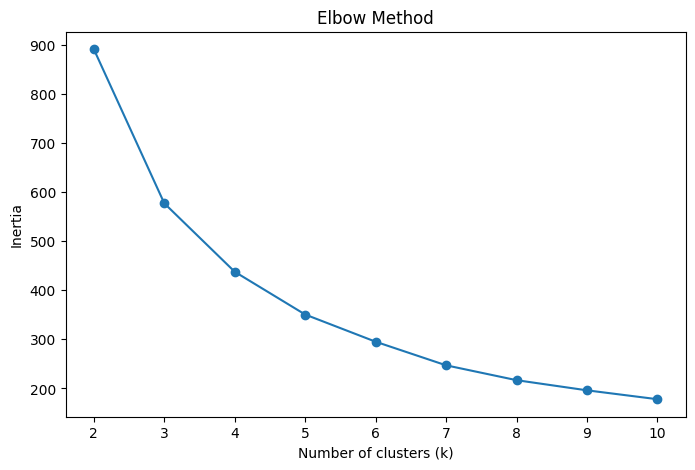

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

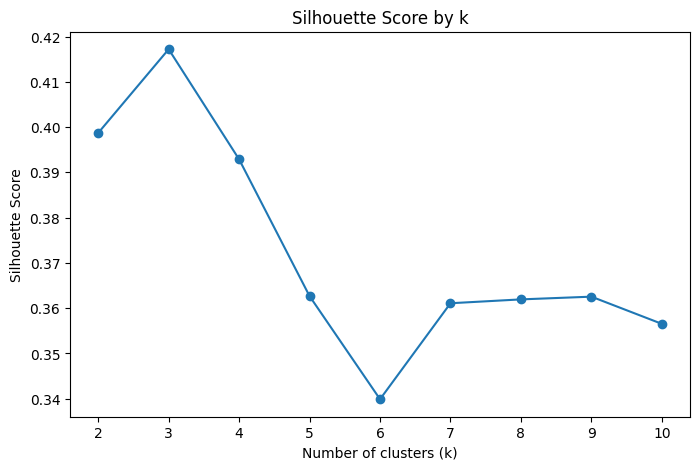

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by k")
plt.show()

# plot shows k = 3 is best 

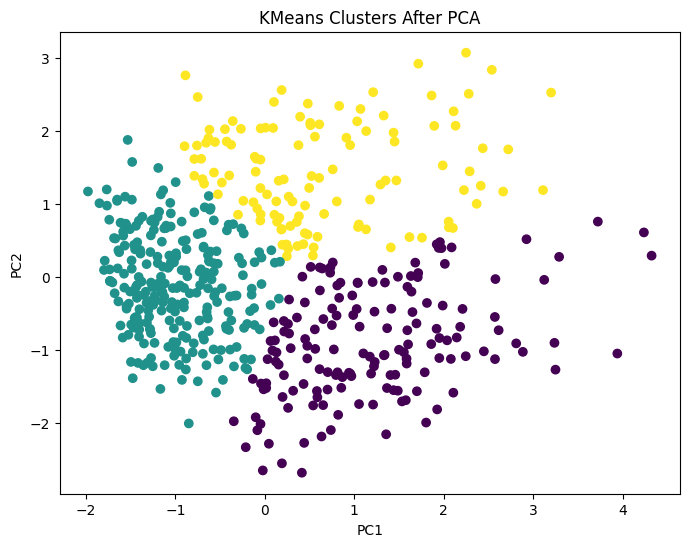

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_processed[:, 0],
    X_processed[:, 1],
    c=np.array(clusters),
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clusters After PCA")

plt.show()

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("pca", PCA(n_components=2)),
    ("kmeans", KMeans(n_clusters=3, random_state=42))
])

pipeline.fit(X)
import joblib

joblib.dump(kmeans, "outputs/final/kmeans_model.pkl")

joblib.dump(
    preprocessor,
    "outputs/final/preprocessor.pkl"
)

joblib.dump(
    pipeline,
    "outputs/final/clustering_pipeline.pkl"
)

cluster_profiles.to_csv(
    "outputs/final/cluster_profiles.csv",
    index=False
)